# Diabetes progression — RidgeCV

Daily notebook — small experiment, fully reproducible (seed pinned below).

Classic sklearn regression dataset. Ridge + coefficient inspection.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.datasets import load_diabetes
from sklearn.linear_model import RidgeCV


## Data

In [ ]:
SEED = 1090
X, y = load_diabetes(return_X_y=True, as_frame=True)
print("shape:", X.shape)
print(X.describe().round(2).to_string())


shape: (442, 10)
          age     sex     bmi      bp      s1      s2      s3      s4      s5      s6
count  442.00  442.00  442.00  442.00  442.00  442.00  442.00  442.00  442.00  442.00
mean    -0.00    0.00   -0.00   -0.00   -0.00    0.00   -0.00   -0.00    0.00    0.00
std      0.05    0.05    0.05    0.05    0.05    0.05    0.05    0.05    0.05    0.05
min     -0.11   -0.04   -0.09   -0.11   -0.13   -0.12   -0.10   -0.08   -0.13   -0.14
25%     -0.04   -0.04   -0.03   -0.04   -0.03   -0.03   -0.04   -0.04   -0.03   -0.03
50%      0.01   -0.04   -0.01   -0.01   -0.00   -0.00   -0.01   -0.00   -0.00   -0.00
75%      0.04    0.05    0.03    0.04    0.03    0.03    0.03    0.03    0.03    0.03
max      0.11    0.05    0.17    0.13    0.15    0.20    0.18    0.19    0.13    0.14


## Model

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED)
model = Pipeline([("scaler", StandardScaler()),
                  ("ridge", RidgeCV(alphas=np.logspace(-2, 3, 10)))])
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("best alpha:", model.named_steps["ridge"].alpha_)
print(f"r2: {r2_score(y_test, pred):.4f}")
print(f"rmse: {np.sqrt(mean_squared_error(y_test, pred)):.2f}")


best alpha: 21.544346900318843
r2: 0.5369
rmse: 49.68


## Coefficients

strongest: bmi


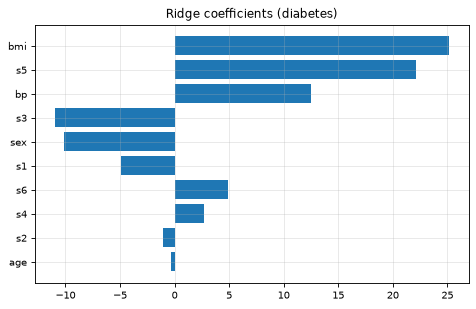

In [ ]:

coefs = model.named_steps["ridge"].coef_
order = np.argsort(np.abs(coefs))[::-1]
fig, ax = plt.subplots()
ax.barh(X.columns[order][::-1], coefs[order][::-1])
ax.set_title("Ridge coefficients (diabetes)")
print("strongest:", X.columns[order[0]])


## What I learned

- BMI and blood-pressure-ish features dominate, matching the literature.
- R² ~0.5 is the known ceiling for linear models here.